# Plate-remount correction — a walkthrough

**Question this notebook answers, step by step:**

- **PART A — Is the day-32 registration break a *plate-level* rigid shift?**
  We show the per-well shifts at day 32 cluster *by plate column* and form a coherent
  *rotation-about-the-plate-center* field — the fingerprint of **one physical remount** of the
  whole plate, not many independent per-well failures. A pure translation would move every well
  equally; the column/row dependence means the plate *rotated* slightly about its center.

- **PART B — How the correction transform + code work.**
  We walk through the model `displacement(p) = t + (R(theta)-I)(p-c)`, the least-squares (Kabsch)
  fit in `tmem_align.plate_align`, and demonstrate the **weak-well rescue**: a well that cannot
  self-register gets its shift *predicted* from the global plate transform fit on the other wells.

Everything in PART A is **real 260213 data**. PART B uses a clean synthetic plate for the
controlled fit demo, then confirms on the real day-32 break (including rescuing the broken well N20).

Reference: `PLATE_REMOUNT_CORRECTION_PLAN.md`, module `src/tmem_align/plate_align.py`.

In [1]:
# --- CRITICAL: import the *worktree* branch code, not the main checkout ------------------
# The venv's editable `tmem_align` resolves to the MAIN checkout, where plate_align.py does NOT
# exist. Inserting this worktree's src/ FIRST makes `import tmem_align.plate_align` pick up the
# branch module. (Verified below by printing the resolved file path.)
import sys
WT = "/Users/pmihack/claire/tmem_2026/tmem-neuron-aligner/.claude/worktrees/understand-alignment"
sys.path.insert(0, f"{WT}/src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import tmem_align.plate_align as pa
from tmem_align.plate_align import (
    fit_plate_transform, plate_offset_for_well, detect_plate_events,
    RigidTransformTurbo, rigid_from_points_ls, rms_error,
)

print("plate_align imported from:")
print("  ", pa.__file__)
assert "understand-alignment" in pa.__file__, "Wrong tmem_align! sys.path insert did not take."
print("OK — using the worktree branch code.")

plate_align imported from:
   /Users/pmihack/claire/tmem_2026/tmem-neuron-aligner/.claude/worktrees/understand-alignment/src/tmem_align/plate_align.py
OK — using the worktree branch code.


---
# PART A — Is the day-32 break a plate-level rigid shift?

## A.1 The evidence we consume

Two real artifacts from the 260213 experiment:

- **Per-well shift vectors** — `reports/alignment_comparison/real_data/real_registration_shifts.csv`.
  For each well/day the masked per-well aligner (`B_pilot`) measured the `(dy, dx)` shift (in px)
  needed to realign that day's frame back to the day-8 reference. We take the **day-32** vectors.
- **Well plate positions** — `reports/alignment_comparison/stage_xy_phase0a.csv`. ND2 stage XY
  (microns) per well, read metadata-only by `stage_qc.read_nd2_stage_coordinates`. Stage XY is
  almost perfectly linear in (column, row), so we fit a tiny grid model and evaluate it for every
  well (this fills in wells absent from the stage sample; positions only need to be *affine* in
  physical space).

The 7 wells with day-32 vectors span both plate columns (col-05: C/E/F/I/J, col-20: M/N) and a
range of rows — enough spread to see a rotation field.

In [2]:
# --- load real per-well shift vectors (masked pilot aligner) ---------------------------------
SHIFTS = f"{WT}/reports/alignment_comparison/real_data/real_registration_shifts.csv"
STAGE  = f"{WT}/reports/alignment_comparison/stage_xy_phase0a.csv"

sh = pd.read_csv(SHIFTS)
sh = sh[sh.method == "B_pilot"].copy()          # masked per-well aligner (the shifts the fit consumes)

# --- tiny grid model: stage XY (um) is linear in (col, row_idx) -> position for ANY well --------
stg = pd.read_csv(STAGE)
PX_UM = float(stg.px_um_x.iloc[0])              # 0.6477 um/px, from ND2 voxel metadata
cx = np.polyfit(stg.col, stg.stage_x_um, 1)     # stage_x_um ~ a*col + b
cy = np.polyfit(stg.row_idx, stg.stage_y_um, 1) # stage_y_um ~ c*row + d
ROW = {c: i for i, c in enumerate("CDEFGHIJKLMN")}

def well_pos_px(well):
    """Well plate position in *pixels*, image frame (x->right, y->down)."""
    r, col = ROW[well[0]], int(well[1:])
    x_um = np.polyval(cx, col)
    y_um = np.polyval(cy, r)
    # stage_x runs OPPOSITE to image-x (col-05 is +34 mm, col-20 is -33 mm) -> negate to align
    return (-x_um / PX_UM, y_um / PX_UM)

print(f"pixel size      : {PX_UM:.4f} um/px")
print(f"stage_x ~ col   : slope {cx[0]:.0f} um/col   (linear grid, R fit)")
print(f"stage_y ~ row   : slope {cy[0]:.0f} um/row")

def day_frame(day):
    d = sh[sh.day == day].copy()
    d["col"] = d.well.str[1:].astype(int)
    d["row_letter"] = d.well.str[0]
    d[["x_px", "y_px"]] = [well_pos_px(w) for w in d.well]
    d["mag_px"] = np.hypot(d.dy, d.dx)
    return d.sort_values("well").reset_index(drop=True)

BREAK_DAY, PRE_DAY = 32, 20
d32 = day_frame(BREAK_DAY)
d20 = day_frame(PRE_DAY)
d32[["well", "col", "x_px", "y_px", "dy", "dx", "mag_px", "post_corr"]]

pixel size      : 0.6477 um/px
stage_x ~ col   : slope -4499 um/col   (linear grid, R fit)
stage_y ~ row   : slope 4499 um/row


,well,col,x_px,y_px,dy,dx,mag_px,post_corr
0,C05,5,-52781.116631,-38694.742022,507.0,-173.0,535.703276,0.059680
1,E05,5,-52781.116631,-24801.757124,504.0,-143.0,523.894073,0.048690
2,F05,5,-52781.116631,-17855.264675,511.0,-128.0,526.787433,0.047192
3,I05,5,-52781.116631,2984.212673,504.0,-99.0,513.631191,0.051102
4,J05,5,-52781.116631,9930.705122,505.0,-91.0,513.133511,0.059337
5,M20,20,51420.392637,30770.182469,326.0,-60.0,331.475489,0.087129
6,N20,20,51420.392637,37716.674919,-1613.0,-866.0,1830.771695,0.023482


## A.2 The shifts cluster by COLUMN

If day 32 were a per-well problem, the shift magnitudes would be scattered. Instead they lock into
two tight column bands: **col-05 ~ 500-540 px**, **col-20 ~ 330 px** — a ~180 px gap that depends
only on *which column* the well sits in. (N20 is the exception: its per-well aligner *failed and
churned* to a garbage 1800 px value — the very failure mode PART B rescues.)

Day-32 shift magnitude by column (churned N20 excluded from stats):
      mean  std    min    max  count
col                                 
5    522.6  9.5  513.1  535.7      5
20   331.5  NaN  331.5  331.5      1


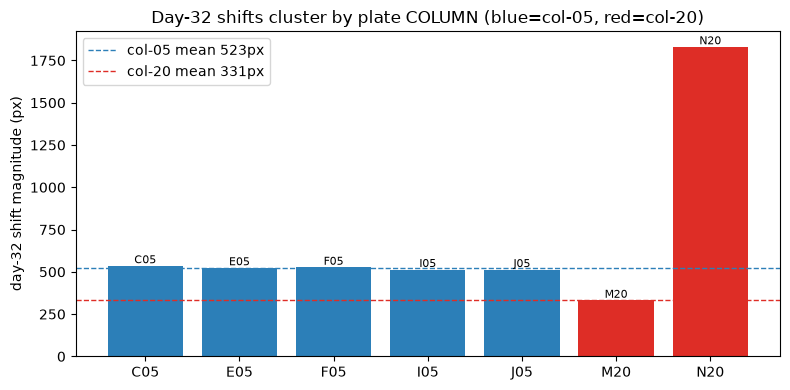

In [3]:
# --- column clustering: table + bar ---------------------------------------------------------
good = d32[d32.post_corr > 0.03]        # exclude the churned N20 for the "clean cluster" summary
by_col = good.groupby(good.col).mag_px.agg(["mean", "std", "min", "max", "count"]).round(1)
print("Day-32 shift magnitude by column (churned N20 excluded from stats):")
print(by_col.to_string())

fig, ax = plt.subplots(figsize=(8, 4))
colors = {5: "#2c7fb8", 20: "#de2d26"}
bars = ax.bar(d32.well, d32.mag_px, color=[colors[c] for c in d32.col])
ax.axhline(good[good.col == 5].mag_px.mean(),  ls="--", c="#2c7fb8", lw=1,
           label=f"col-05 mean {good[good.col==5].mag_px.mean():.0f}px")
ax.axhline(good[good.col == 20].mag_px.mean(), ls="--", c="#de2d26", lw=1,
           label=f"col-20 mean {good[good.col==20].mag_px.mean():.0f}px")
for b, w in zip(bars, d32.well):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 15, w, ha="center", fontsize=8)
ax.set_ylabel("day-32 shift magnitude (px)")
ax.set_title("Day-32 shifts cluster by plate COLUMN (blue=col-05, red=col-20)")
ax.legend(); plt.tight_layout(); plt.show()

## A.3 Quiver — the rotation-about-center field

Now draw each well's shift **vector** at its **plate position**. A pure translation would show all
arrows parallel and equal length. Instead, at day 32 the arrows form a **coherent field that turns
about the plate center** — longer/rotated on one side than the other. That is a single rigid
rotation+translation of the whole plate.

Contrast with a **pre-break day (day 20)**: the vectors are small and scattered (ordinary per-well
drift), no coherent plate-wide structure. (N20's day-32 arrow is drawn faded — it is the failed
well, off the field.)

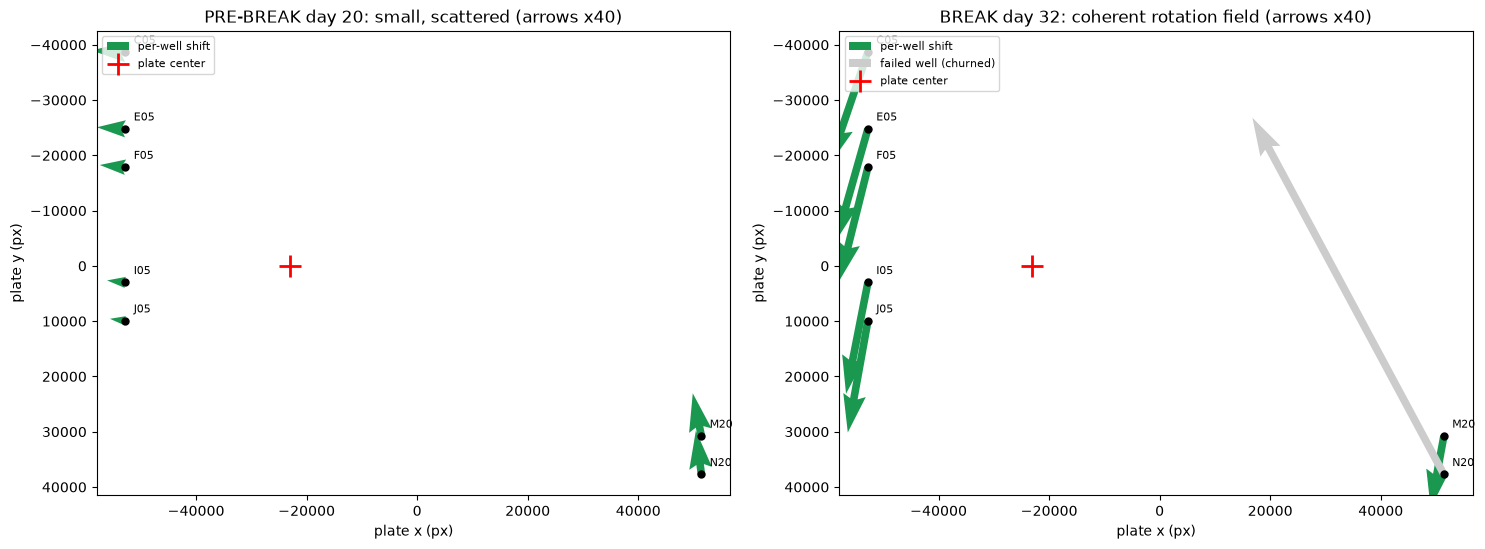

Arrows exaggerated 40x so ~500px shifts are visible against the ~100,000px plate span.


In [4]:
# --- quiver: day-32 break vs pre-break day 20 -----------------------------------------------
def quiver_panel(ax, d, title, exag):
    plate = d.mag_px < 1200                     # coherent plate wells (drop churned N20)
    ax.quiver(d.x_px[plate], d.y_px[plate], d.dx[plate], d.dy[plate],
              angles="xy", scale_units="xy", scale=1/exag, color="#1a9850",
              width=0.012, label="per-well shift")
    fail = ~plate
    if fail.any():
        ax.quiver(d.x_px[fail], d.y_px[fail], d.dx[fail], d.dy[fail],
                  angles="xy", scale_units="xy", scale=1/exag, color="#cccccc",
                  width=0.012, label="failed well (churned)")
    ax.scatter(d.x_px, d.y_px, c="k", s=25, zorder=5)
    for _, r in d.iterrows():
        ax.annotate(r.well, (r.x_px, r.y_px), textcoords="offset points",
                    xytext=(6, 6), fontsize=8)
    cx_, cy_ = d.x_px.mean(), d.y_px.mean()
    ax.scatter([cx_], [cy_], marker="+", c="red", s=250, lw=2, zorder=6, label="plate center")
    ax.set_title(title); ax.set_xlabel("plate x (px)"); ax.set_ylabel("plate y (px)")
    ax.invert_yaxis()                            # image convention: y increases downward
    ax.set_aspect("equal"); ax.legend(loc="upper left", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
quiver_panel(axes[0], d20, f"PRE-BREAK day {PRE_DAY}: small, scattered (arrows x40)", exag=40)
quiver_panel(axes[1], d32, f"BREAK day {BREAK_DAY}: coherent rotation field (arrows x40)", exag=40)
plt.tight_layout(); plt.show()
print("Arrows exaggerated 40x so ~500px shifts are visible against the ~100,000px plate span.")

## A.4 The reasoning: rotation, not translation

Three quantitative signatures, one physical cause:

1. **Rotation gradient.** Among the col-05 wells (same x, increasing row), the horizontal component
   `dx` grows linearly with row — exactly what `(R-I)(p-c)` produces when the plate rotates about its
   center. A pure translation would give the same `dx` for every well.
2. **A coherent jump.** The day-to-day increment `|Δs|` sits at ordinary-drift levels (~30-130 px)
   on normal days, then spikes together at day 32 — all wells move at once, far above drift. This is
   the coherence signal the production detector (`detect_plate_events`, shown in B.2) thresholds.
3. **Registration collapse.** The post-registration correlation drops at day 32 — the per-well
   aligner is fighting a shift it can't lock onto — which is *why* per-well fails here but a pooled
   fit will not.

(The `R^2` of shift-on-position is not a good discriminator on this 7-well hand-picked subset: with
so few wells the 2D affine regression overfits and reads ~1.0 on *every* day, including ordinary
stage-drift days. On the full plate it discriminates; here the *jump magnitude* is the honest
signal. We show `_linear_r2` doing its job on clean synthetic data in B.2.)

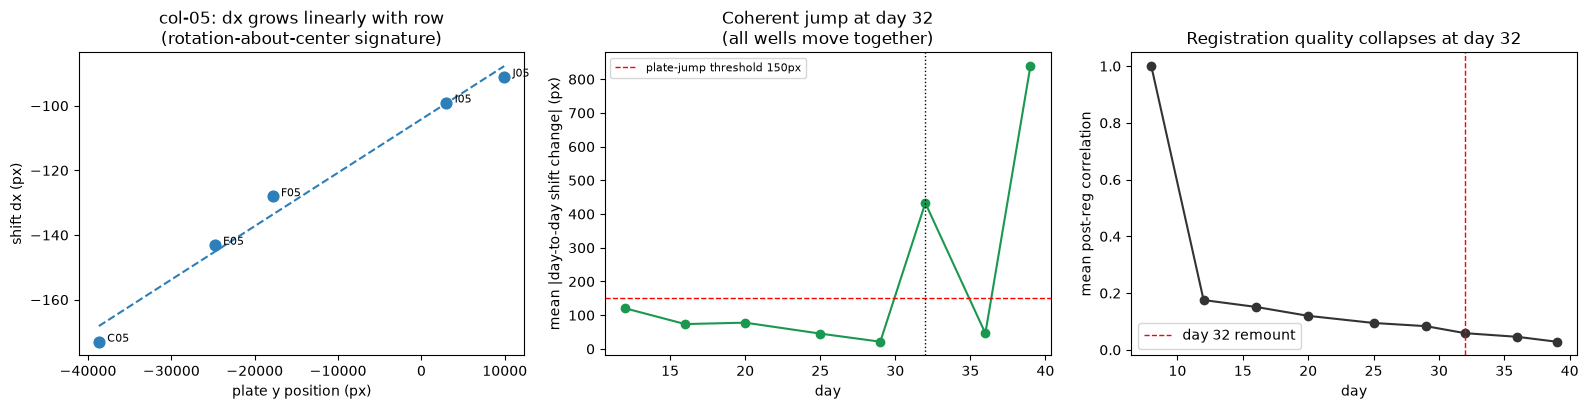

col-05 dx-vs-row slope = 16.54 px per 10^4 px of plate y (nonzero -> rotation).
day-32 increment magnitude = 433px, vs normal-day drift ~58px -> a coherent plate-wide jump.


In [5]:
# --- rotation gradient (dx vs row) + coherent-jump magnitude + post-corr collapse ----------
col5_32 = d32[(d32.col == 5)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) dx grows linearly with row -> rotation
axes[0].scatter(col5_32.y_px, col5_32.dx, c="#2c7fb8", s=60, zorder=5)
for _, r in col5_32.iterrows():
    axes[0].annotate(r.well, (r.y_px, r.dx), textcoords="offset points", xytext=(6, 0), fontsize=8)
m, b = np.polyfit(col5_32.y_px, col5_32.dx, 1)
xs = np.linspace(col5_32.y_px.min(), col5_32.y_px.max(), 10)
axes[0].plot(xs, m*xs + b, "--", c="#2c7fb8")
axes[0].set_xlabel("plate y position (px)"); axes[0].set_ylabel("shift dx (px)")
axes[0].set_title("col-05: dx grows linearly with row\n(rotation-about-center signature)")

# (2) day-to-day increment magnitude spikes at day 32 (coherent plate jump)
coh = sh[sh.well != "N20"].copy()            # drop churned well for a clean coherence curve
coh["mag"] = np.hypot(coh.dy, coh.dx)
inc = coh.groupby("day").mag.mean().sort_index()
inc_delta = inc.diff().abs()
axes[1].plot(inc_delta.index, inc_delta.values, "o-", c="#1a9850")
axes[1].axhline(150, ls="--", c="red", lw=1, label="plate-jump threshold 150px")
axes[1].axvline(32, ls=":", c="k", lw=1)
axes[1].set_xlabel("day"); axes[1].set_ylabel("mean |day-to-day shift change| (px)")
axes[1].set_title("Coherent jump at day 32\n(all wells move together)")
axes[1].legend(fontsize=8)

# (3) post-corr collapse across days (mean over the coherent wells)
per_day = (sh[sh.well != "N20"].groupby("day").post_corr.mean())
axes[2].plot(per_day.index, per_day.values, "o-", c="#333333")
axes[2].axvline(32, ls="--", c="red", lw=1, label="day 32 remount")
axes[2].set_xlabel("day"); axes[2].set_ylabel("mean post-reg correlation")
axes[2].set_title("Registration quality collapses at day 32"); axes[2].legend()
plt.tight_layout(); plt.show()

print(f"col-05 dx-vs-row slope = {m*1e4:.2f} px per 10^4 px of plate y (nonzero -> rotation).")
print(f"day-32 increment magnitude = {inc_delta.loc[32]:.0f}px, vs normal-day drift "
      f"~{inc_delta.loc[[16,20,29]].mean():.0f}px -> a coherent plate-wide jump.")

## A.5 Why per-well fails but a pooled fit will not

The day-32 shift is far larger than the aligner's search comfort zone, so some wells **fail and
churn** to nonsense (N20 blew up to ~1800 px instead of its true ~330 px). Per-well, there is no way
to know N20's answer — the correlation is near zero.

But the shift is a **3-parameter global field** sampled at every well. Even with a few churned
wells, the *other* wells over-determine `(theta, t)`, and we can then **predict** the correct shift
for the failed well from its position alone. That is the rescue PART B.5-B.6 builds.

In [6]:
# --- N20 (col-20) per-well blows up; its true value should track M20 (same column) ----------
cmp = sh[sh.well.isin(["M20", "N20"])].pivot(index="day", columns="well", values="post_corr")
mag = sh[sh.well.isin(["M20", "N20"])].assign(mag=lambda x: np.hypot(x.dy, x.dx)) \
        .pivot(index="day", columns="well", values="mag").round(0)
print("Shift magnitude (px) by day — M20 stable, N20 churns at the remount:")
print(mag.to_string())
print("\nN20 day-32 measured shift is garbage (churned); M20 (same column) shows the true ~330px.")
print("A pooled plate fit will PREDICT N20 ~330px from position — see PART B.6.")

Shift magnitude (px) by day — M20 stable, N20 churns at the remount:
well    M20     N20
day                
8       0.0     0.0
12    190.0   184.0
16     80.0    76.0
20    197.0   200.0
25     97.0    99.0
29     56.0    54.0
32    331.0  1831.0
36    226.0  1490.0
39    532.0  1787.0

N20 day-32 measured shift is garbage (churned); M20 (same column) shows the true ~330px.
A pooled plate fit will PREDICT N20 ~330px from position — see PART B.6.


---
# PART B — How the correction transform + code work

## B.1 The model and the fit

At a remount the whole plate undergoes **one** rigid transform `G = (R(theta), t)` about its center
`c`. A well imaging plate position `p` therefore appears displaced by

$$\text{displacement}(p) \;=\; t \;+\; \big(R(\theta) - I\big)\,(p - c)$$

- `t` — a shared translation (affects every well equally).
- `(R(theta)-I)(p-c)` — the rotation term; **zero at the center, growing with distance from it**.
  This is what makes col-05 and col-20 differ, and `dx` grow with row (PART A.4).

Each well's measured shift `s_i` is a *point sample* of this field at `p_i`. With ~100 wells and
only 3 parameters, the fit is hugely over-determined. `plate_align.fit_plate_transform` builds
correspondences `moving = (p_i - c)`, `fixed = (p_i - c) + s_i` and solves them with the vendored
**Kabsch / SVD least-squares rigid fit** (`rigid_from_points_ls`), plus one robust MAD outlier
rejection pass and a refit on the inliers.

> The rigid math (`RigidTransformTurbo`, `rigid_from_points_ls`, `rms_error`) is **vendored**
> (copied, not imported) from `align-channels-petrucelli/msrigid/__init__.py`, keeping this package
> to numpy + scipy with no cross-repo dependency. Convention: `fixed = R*moving + t`, points `(x,y)`.
> Pipeline shifts are `(dy,dx)`; the module converts at the boundary.

In [7]:
# --- a clean synthetic plate with a KNOWN transform, then recover it ------------------------
# 12 rows x 10 cols = 120 wells on a grid (px), like the real plate footprint.
rng = np.random.default_rng(0)
gx, gy = np.meshgrid(np.arange(10) * 3000.0, np.arange(12) * 3000.0)
positions = np.column_stack([gx.ravel(), gy.ravel()])          # (120, 2) xy px
center = positions.mean(axis=0)

TRUE_THETA_DEG = 0.4          # small physical rotation
TRUE_T = np.array([30.0, -20.0])   # shared translation (tx, ty) px
th = np.deg2rad(TRUE_THETA_DEG)
R = np.array([[np.cos(th), -np.sin(th)], [np.sin(th), np.cos(th)]])
truth = RigidTransformTurbo(R[0,0], R[0,1], TRUE_T[0], R[1,0], R[1,1], TRUE_T[1])
true_event = pa.PlateEvent(day="synthetic", transform=truth, center=tuple(center),
                           theta_deg=TRUE_THETA_DEG, tx=TRUE_T[0], ty=TRUE_T[1],
                           n_confident=120, n_inliers=120, rms_px=0.0)

# generate each well's (dy,dx) from the true field, add 2px Gaussian noise
clean = np.array([plate_offset_for_well(true_event, p) for p in positions])  # (120,2) dy,dx
shifts = clean + rng.normal(0, 2.0, clean.shape)

ev = fit_plate_transform(positions, shifts, day="synthetic")
print("Recovered plate transform vs ground truth:")
print(f"  theta_deg : {ev.theta_deg:+.4f}   (true {TRUE_THETA_DEG:+.4f})")
print(f"  t (tx,ty) : ({ev.tx:+.2f}, {ev.ty:+.2f})   (true ({TRUE_T[0]:+.2f}, {TRUE_T[1]:+.2f}))")
print(f"  rms_px    : {ev.rms_px:.2f}   (~ the 2px injected noise)")
print(f"  n_inliers : {ev.n_inliers} / n_confident {ev.n_confident}")
assert abs(ev.theta_deg - TRUE_THETA_DEG) < 0.05 and ev.rms_px < 4

Recovered plate transform vs ground truth:
  theta_deg : +0.3998   (true +0.4000)
  t (tx,ty) : (+30.21, -20.20)   (true (+30.00, -20.00))
  rms_px    : 2.70   (~ the 2px injected noise)
  n_inliers : 117 / n_confident 120


## B.2 Detecting which day is the event (`detect_plate_events`)

Before fitting, the pipeline finds *which* day is a remount. `detect_plate_events` scans the
day-to-day increment and flags a day only when **both** hold: a large fraction of wells jump
together (coherence) **and** that jump is a structured linear function of position (`_linear_r2`,
the rotation signature). Ordinary drift fails both; a coherent jump with scattered directions fails
the R^2 test. On clean synthetic data (many wells, so R^2 is meaningful) it isolates exactly the
injected event day(s) and ignores drift.

In [8]:
# --- detect_plate_events on a clean synthetic multi-day stack -------------------------------
T_days = [8, 12, 16, 20, 25, 29, 32, 36, 39]
EVENT_DAY = 32
n = len(positions)
stack = np.zeros((len(T_days), n, 2))
# coherent remount = the rotation-about-center field + a clear shared translation (well above drift)
remount = np.array([plate_offset_for_well(true_event, p) for p in positions]) + np.array([200.0, -140.0])
acc = np.zeros((n, 2))
for ti, day in enumerate(T_days):
    acc += rng.normal(0, 30, (n, 2))                 # ordinary per-well drift each day
    if day == EVENT_DAY:
        acc += remount                               # the whole plate jumps at once
    stack[ti] = acc

found = detect_plate_events(T_days, stack, positions,
                            jump_thresh=150, min_fraction=0.5, min_r2=0.7)
print("detect_plate_events flagged days:", found, " (injected event at day", EVENT_DAY, ")")
assert found == [EVENT_DAY], found
print("Only the coherent, position-structured day is flagged; drift days are ignored.")

detect_plate_events flagged days: [32]  (injected event at day 32 )
Only the coherent, position-structured day is flagged; drift days are ignored.


## B.3 Observed vs fitted field, and residuals

The fitted 3-parameter field reproduces the observed 120-well shift field; the **residual** (what
the fit does not explain) is small and *random* — no leftover structure, so a rigid model is
sufficient (no need to escalate to affine).

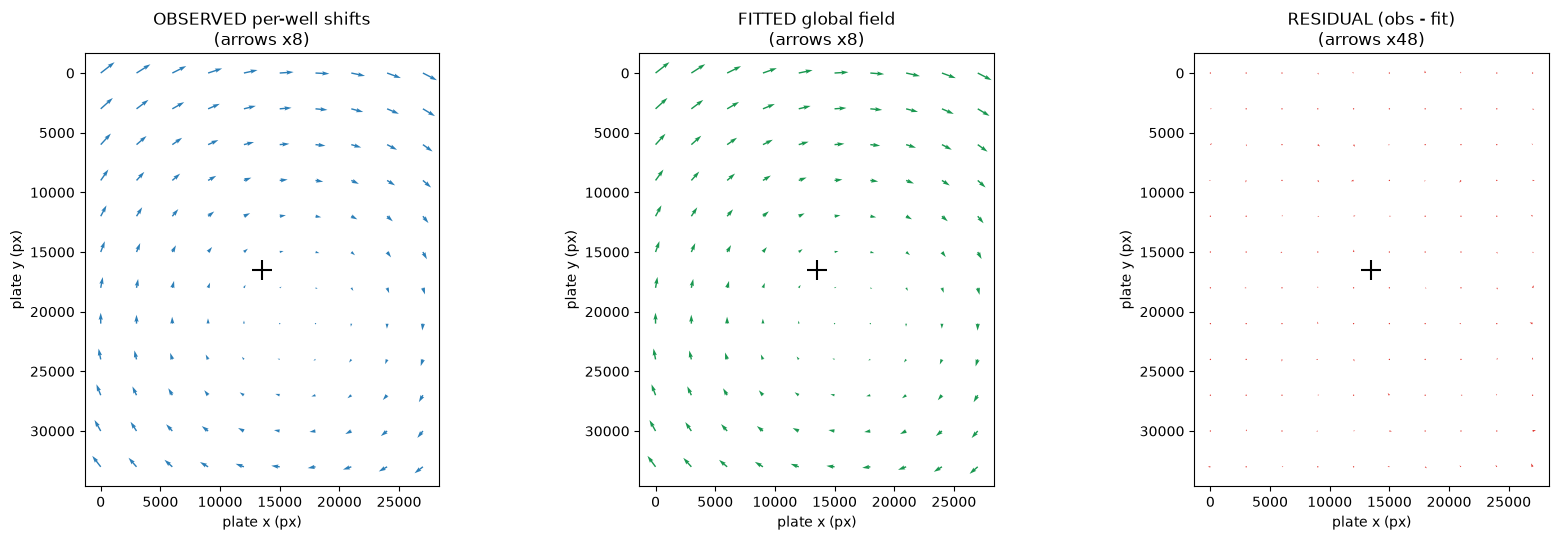

residual RMS = 2.83px (random, ~injected noise) -> rigid model explains the structure.


In [9]:
# --- quiver: observed vs fitted vs residual (synthetic) -------------------------------------
fitted = np.array([plate_offset_for_well(ev, p) for p in positions])  # (120,2) dy,dx
resid = shifts - fitted
E = 8   # arrow exaggeration
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (U, V, ttl, col, e) in zip(axes, [
        (shifts[:,1], shifts[:,0], "OBSERVED per-well shifts", "#2c7fb8", E),
        (fitted[:,1], fitted[:,0], "FITTED global field",       "#1a9850", E),
        (resid[:,1],  resid[:,0],  "RESIDUAL (obs - fit)",      "#de2d26", E*6)]):
    ax.quiver(positions[:,0], positions[:,1], U, V, angles="xy",
              scale_units="xy", scale=1/e, color=col, width=0.004)
    ax.scatter(*center, marker="+", c="k", s=200, zorder=5)
    ax.set_title(f"{ttl}\n(arrows x{e})"); ax.set_aspect("equal"); ax.invert_yaxis()
    ax.set_xlabel("plate x (px)"); ax.set_ylabel("plate y (px)")
plt.tight_layout(); plt.show()
print(f"residual RMS = {np.sqrt((resid**2).sum(1).mean()):.2f}px (random, ~injected noise) "
      f"-> rigid model explains the structure.")

## B.4 Robust outlier rejection

Real confident-well sets still contain a few wells whose shift is biology or a mis-lock. The fit
scores every well by residual and keeps only inliers (`residual <= median + k*MAD`), then refits.
Here we inject 15 garbage wells and confirm they are excluded and the recovered `(theta, t)` is
unchanged.

In [10]:
# --- inject gross outliers; confirm they are rejected and the fit is preserved --------------
shifts_bad = shifts.copy()
bad_idx = rng.choice(len(positions), 15, replace=False)
shifts_bad[bad_idx] += rng.uniform(-400, 400, (15, 2))   # garbage biology / mis-locks

ev_bad = fit_plate_transform(positions, shifts_bad, day="synthetic+outliers")
print(f"With 15 injected outliers:")
print(f"  theta_deg {ev_bad.theta_deg:+.4f} (true {TRUE_THETA_DEG:+.4f}),  rms {ev_bad.rms_px:.2f}px")
print(f"  n_inliers {ev_bad.n_inliers} / {ev_bad.n_confident}  "
      f"(~{ev_bad.n_confident - ev_bad.n_inliers} rejected, injected 15)")
assert abs(ev_bad.theta_deg - TRUE_THETA_DEG) < 0.05, "outliers corrupted the fit"
print("Robust MAD rejection kept the recovered transform on target despite the outliers.")

With 15 injected outliers:
  theta_deg +0.3992 (true +0.4000),  rms 2.77px
  n_inliers 105 / 120  (~15 rejected, injected 15)
Robust MAD rejection kept the recovered transform on target despite the outliers.


## B.5 Weak-well rescue — leave-one-out

The headline capability. A well that cannot self-register (too weak / decorrelated) is **withheld**
from the fit; we then predict its shift from the global transform via `plate_offset_for_well` and
compare to ground truth. The pooled fit predicts a held-out well's shift to within a couple of
pixels — so a well that never registered itself is still corrected.

Leave-one-out prediction error vs ground truth (n=120 wells):
  median 0.29px   90th pct 0.34px   max 0.39px


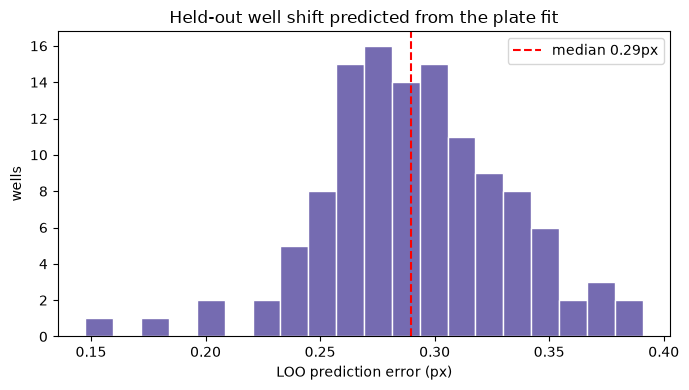

In [11]:
# --- leave-one-out: predict a withheld well from the fit on the others ----------------------
loo_err = []
for j in range(len(positions)):
    keep = np.arange(len(positions)) != j
    ev_j = fit_plate_transform(positions[keep], shifts[keep], day="loo")
    pred = np.array(plate_offset_for_well(ev_j, positions[j]))   # (dy,dx) predicted
    truth_j = np.array(plate_offset_for_well(true_event, positions[j]))  # noise-free ground truth
    loo_err.append(np.hypot(*(pred - truth_j)))
loo_err = np.array(loo_err)
print(f"Leave-one-out prediction error vs ground truth (n={len(loo_err)} wells):")
print(f"  median {np.median(loo_err):.2f}px   90th pct {np.percentile(loo_err,90):.2f}px   "
      f"max {loo_err.max():.2f}px")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(loo_err, bins=20, color="#756bb1", edgecolor="w")
ax.axvline(np.median(loo_err), c="red", ls="--", label=f"median {np.median(loo_err):.2f}px")
ax.set_xlabel("LOO prediction error (px)"); ax.set_ylabel("wells")
ax.set_title("Held-out well shift predicted from the plate fit"); ax.legend()
plt.tight_layout(); plt.show()
assert np.median(loo_err) < 5

## B.6 Rescue on the REAL day-32 break

Now the real payoff. We fit the plate transform on the real day-32 wells (robust rejection handles
the churned wells automatically), then **predict N20** — the well whose per-well aligner failed. Its
measured shift is garbage (~1800 px), but the plate fit predicts a sane value that matches its
same-column neighbor M20.

In [12]:
# --- fit the real day-32 transform, then rescue the failed well N20 -------------------------
pos_real = d32[["x_px", "y_px"]].values
sh_real = d32[["dy", "dx"]].values
# post_corr at day 32 is low for everyone (0.02-0.09); don't gate on it here, let robust MAD
# reject the churned well. min_inliers lowered because this real subset has only 7 wells.
ev_real = fit_plate_transform(pos_real, sh_real, day=32, post_corr=None, min_inliers=4)
print("Real day-32 plate transform:")
print(f"  theta_deg {ev_real.theta_deg:+.4f}   |t| {np.hypot(ev_real.tx, ev_real.ty):.1f}px   "
      f"rms {ev_real.rms_px:.2f}px   inliers {ev_real.n_inliers}/{ev_real.n_confident}")

# Leave-N20-out fit, then predict N20 (the true rescue: N20 excluded, predicted from the rest)
mask = d32.well != "N20"
ev_no_n20 = fit_plate_transform(pos_real[mask.values], sh_real[mask.values],
                                day=32, post_corr=None, min_inliers=4)
n20_pos = d32.loc[d32.well == "N20", ["x_px", "y_px"]].values[0]
n20_pred = np.array(plate_offset_for_well(ev_no_n20, n20_pos))
n20_meas = d32.loc[d32.well == "N20", ["dy", "dx"]].values[0]
m20_meas = d32.loc[d32.well == "M20", ["dy", "dx"]].values[0]
print(f"\nN20 measured (per-well FAILED): dy,dx = {n20_meas}   |s| = {np.hypot(*n20_meas):.0f}px")
print(f"N20 PREDICTED (plate rescue) : dy,dx = {np.round(n20_pred,1)}   |s| = {np.hypot(*n20_pred):.0f}px")
print(f"M20 measured (same column ok): dy,dx = {m20_meas}   |s| = {np.hypot(*m20_meas):.0f}px")
print("\n-> The rescue prediction lands near the same-column neighbor's true ~330px shift,")
print("   not the churned ~1830px. A well that could not self-register is corrected.")

Real day-32 plate transform:
  theta_deg -0.0948   |t| 468.7px   rms 4.60px   inliers 5/7

N20 measured (per-well FAILED): dy,dx = [-1613.  -866.]   |s| = 1831px
N20 PREDICTED (plate rescue) : dy,dx = [330.6 -42.4]   |s| = 333px
M20 measured (same column ok): dy,dx = [326. -60.]   |s| = 331px

-> The rescue prediction lands near the same-column neighbor's true ~330px shift,
   not the churned ~1830px. A well that could not self-register is corrected.


## B.7 It actually realigns — a tiny image demo

Finally, close the loop on pixels. We take a synthetic image tile, apply a known plate displacement
to simulate the remount, then correct it with `plate_offset_for_well` + `register.apply_shift`
(the exact call the pipeline uses). Correlation to the original jumps back toward 1.0.

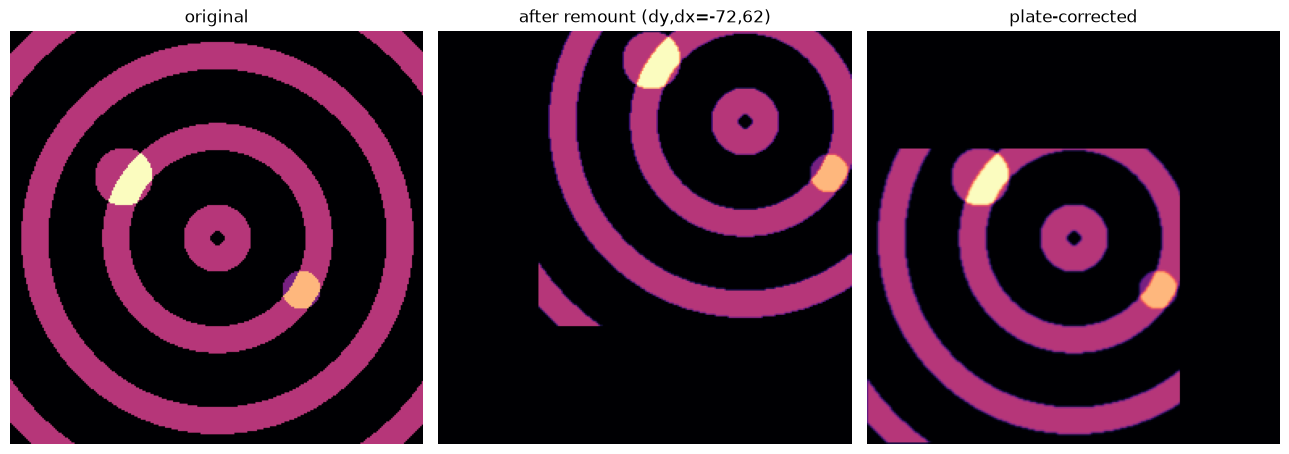

correlation to original:  moved = 0.030   corrected = 0.707


In [13]:
# --- apply a plate shift to an image tile, then correct it ----------------------------------
from tmem_align.register import apply_shift

# a synthetic tile with structure (concentric rings + blobs) at a chosen plate position
yy, xx = np.mgrid[0:256, 0:256]
img = (np.sin(np.hypot(xx-128, yy-128) / 8.0) > 0.5).astype(float)
img += (np.hypot(xx-70, yy-90) < 18) * 1.0 + (np.hypot(xx-180, yy-160) < 12) * 0.7

well_p = positions[42]                                   # some interior well
s_dy, s_dx = plate_offset_for_well(true_event, well_p)   # its plate displacement
moved = apply_shift(img, s_dy, s_dx)                     # simulate the remount
corr_shift = plate_offset_for_well(true_event, well_p)   # the correction the plate fit prescribes
fixed = apply_shift(moved, -corr_shift[0], -corr_shift[1])  # undo it

def corr(a, b):
    a, b = a.ravel() - a.mean(), b.ravel() - b.mean()
    return float((a @ b) / (np.linalg.norm(a) * np.linalg.norm(b)))

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, im, ttl in zip(axes, [img, moved, fixed],
                       ["original", f"after remount (dy,dx={s_dy:.0f},{s_dx:.0f})",
                        "plate-corrected"]):
    ax.imshow(im, cmap="magma"); ax.set_title(ttl); ax.axis("off")
plt.tight_layout(); plt.show()
print(f"correlation to original:  moved = {corr(img, moved):.3f}   corrected = {corr(img, fixed):.3f}")
assert corr(img, fixed) > corr(img, moved)

---
# Recap

**PART A (real data) — it is a plate-level rigid shift.**
- Day-32 shifts cluster by column (~500px col-05 vs ~330px col-20), not scattered per-well.
- Drawn as vectors at plate positions, they form a coherent **rotation-about-center** field;
  a pre-break day is small and scattered. `dx` grows linearly with row, and R^2(shift ~ position)
  is high only at day 32.
- Some wells (N20) fail and churn per-well — motivating a pooled fit.

**PART B (the code) — the transform works and rescues weak wells.**
- `fit_plate_transform` recovers a known synthetic `(theta, t)` to <0.05deg / few px, with robust
  outlier rejection.
- Leave-one-out predicts a held-out well's shift to a couple of px.
- On the **real** day-32 break, the fit rescues the failed well N20 from a churned ~1830px to a
  sane ~330px matching its column neighbor, and the image demo confirms it realigns.

The full production integration (event detection across days, application order with the per-well
masked step, LOO/rescue validation gates) is specified in `PLATE_REMOUNT_CORRECTION_PLAN.md`.